In [1]:
import numpy as np
import pandas as pd
np.set_printoptions(edgeitems=30, linewidth=200) # 적당히 보기 편한 값으로 수정 필요.
from modules.utils import generate_orthonormal_states

import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm

G_layers = 10
n_qubits = 3

dim = 2**n_qubits
number_of_basis = 2
basis_states = generate_orthonormal_states(dim, number_of_basis, mode='real')
code_qubits = number_of_basis

smooth = 0.0
BATCH_SIZE = 16

print("Orthogonal states shape:", basis_states.shape)  # (number_of_basis, dim)
assert np.allclose(basis_states @ basis_states.T.conj(), np.eye(number_of_basis)), "state vectors are not orthogonal"

Orthogonal states shape: (2, 8)


In [2]:
from torch.autograd import Variable
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import pennylane as qml

import importlib
from modules import QGAN, Discriminator, MINE  # 초기 import
importlib.reload(QGAN)  # 모듈 갱신
importlib.reload(Discriminator)  # 모듈 갱신
importlib.reload(MINE)  # 모듈 갱신


train_type = "InfoQGAN"
use_mine = True if train_type == "InfoQGAN" else False

ml_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
quantum_device = qml.device("default.qubit", wires=n_qubits)
print("고전 머신러닝 device =", ml_device, "양자 회로 backend =", quantum_device)

generator_initial_params = Variable(torch.tensor(np.random.normal(-np.pi, np.pi, (G_layers, n_qubits, 1))), requires_grad=True)
generator = QGAN.QGenerator(n_qubits, n_qubits, G_layers, generator_initial_params, quantum_device, mode="RY") # 상태를 얻어야 Discriminator에 넣음.

discriminator = Discriminator.LinearDiscriminator(input_dim = 2**n_qubits, hidden_size=100) # 50 --> 25 변경

mine = MINE.LinearMine(code_dim=code_qubits, output_dim=2**n_qubits, size=100)

고전 머신러닝 device = cpu 양자 회로 backend = <default.qubit device (wires=3) at 0x19db4808160>


In [3]:
def combine_quantum_states(states, train_size, combine_mode):
    # combine given quantum states to generate combined quantum states
    assert combine_mode in ["linspace", "uniform"], "combine_mode should be 'linspace' or 'uniform'"
    num_of_states = len(states)
    dim_of_states = len(states[0])

    if combine_mode == "uniform":
        # use dirichlet distribution to generate random weights
        alpha = np.ones(num_of_states)
        matrix = np.random.dirichlet(alpha, size=train_size)
        coeff = np.sqrt(matrix)
        combined_states = np.dot(coeff, states)
        return combined_states
    
    elif combine_mode == "linspace":
        pass #TODO: linspace방법도 구현한 다음 비교하자. train_size조건이 좀 까다로울듯


In [4]:
train_size = 300

train_dataset = combine_quantum_states(basis_states, train_size, "uniform")
train_tensor = torch.tensor(train_dataset, dtype=torch.float32) # dtype = complex
assert np.allclose(np.linalg.norm(train_dataset, axis=1), np.ones(train_size)), "combined states are not normalized"

In [5]:
G_lr = 0.001
D_lr = 0.0001
M_lr = 0.001
COEFF = 0.05
G_opt = torch.optim.Adam([generator.params], lr=G_lr)
D_opt = torch.optim.Adam(discriminator.parameters(), lr=D_lr)
M_opt = torch.optim.Adam(mine.parameters(), lr=M_lr)

In [6]:
def generator_train_step(generator_seed, coeff, use_mine = False):
    '''
    params (torch.Tensor(레이어,큐빗,3)): a parameter
    generator_input (torch.Tensor(BATCH_SIZE, seed_dim)): 생성기 입력 seed (code+noise).
    '''
    code_input = generator_seed[:, :code_qubits] # 입력중에서 code만 뽑는다. (BATCH_SIZE, code_qubits)
    generator_states = generator.forward(generator_seed) # 출력을 뽑아낸다 (BATCH_SIZE, 2**output_qubits) * 2
    generator_probs = abs(generator_states).to(torch.float32)
    generator_states = generator_states.to(torch.float32)
    
    disc_output = discriminator(generator_states) # 밑에 코드에서 정의됨
    gan_loss = torch.log(1-disc_output).mean()
    
    if use_mine:
        pred_xy = mine(code_input, generator_probs)
        code_input_shuffle = code_input[torch.randperm(BATCH_SIZE)]
        pred_x_y = mine(code_input_shuffle, generator_probs)
        mi = torch.mean(pred_xy) - torch.log(torch.mean(torch.exp(pred_x_y)))
        gan_loss -= coeff * mi

    return generator_probs, generator_states, gan_loss

disc_loss_fn = nn.BCELoss()
def disc_cost_fn(real_input, fake_input):
    batch_num = real_input.shape[0]

    disc_real = discriminator(real_input)
    disc_fake = discriminator(fake_input)

    real_label = torch.ones((batch_num, 1)).to(ml_device)
    fake_label = torch.zeros((batch_num, 1)).to(ml_device)
    
    if smooth > 0.00001:
        real_label = real_label - smooth*torch.rand(real_label.shape).to(ml_device)
    
    loss = 0.5 * (disc_loss_fn(disc_real, real_label) + disc_loss_fn(disc_fake, fake_label))
    
    return loss

In [7]:
import seaborn as sns

def visualize_output_simple(magnitudes, correlation_matrix, epoch, writer, image_file_path):
    # 1. 첫 번째 플롯: 각 basis_states에 사영시켰을 때, 차지하는 평균 비중 시각화
    avg_magnitudes = magnitudes.mean(axis=0)
    plt.figure()
    plt.bar(range(number_of_basis), avg_magnitudes)
    plt.title(f"epoch = {epoch}")
    plt.xlabel("Index")
    plt.ylabel("Projection Magnitude")
    # save plt
    plt.savefig(f'{image_file_path}/projection_epoch{epoch:03d}.png')
    writer.add_figure(f'Projection Magnitude', plt.gcf(), epoch)
    plt.close()

    # 2. 두 번째 플롯: 각 code에 대해 basis state의 설명력 시각화
    plt.figure(figsize=(10, 6))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
                xticklabels=[f"Basis {j+1}" for j in range(number_of_basis)], 
                yticklabels=[f"Code {i+1}" for i in range(n_qubits)])
    plt.title(f"Correlation Heatmap between Code and Basis magnitudes (Epoch = {epoch})")
    plt.xlabel("Output Dimensions")
    plt.ylabel("Input Dimensions")
    plt.savefig(f'{image_file_path}/correlation_heatmap{epoch:03d}.png')
    writer.add_figure(f'Correlation Heatmap', plt.gcf(), epoch)
    plt.close()

In [12]:
import time
import os
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter

current_time = datetime.now().strftime("%b%d_%H_%M_%S")  # "Aug13_14_12_30" 형식
save_dir = f"./runs/pure_{train_type}_{current_time}"
scalar_save_path = os.path.join(save_dir, f"pure_{train_type}_{current_time}.csv")
image_save_dir = os.path.join(save_dir, "images")
param_save_dir = os.path.join(save_dir, "params")
os.makedirs(image_save_dir, exist_ok=True)
os.makedirs(param_save_dir, exist_ok=True)

writer = SummaryWriter(log_dir=save_dir)

In [13]:
# CSV 파일 초기화 (헤더 작성)
df = pd.DataFrame(columns=['epoch', 'D_loss', 'G_loss', 'MI', 'Rsum', 'time'] + 
                  [f'c{i}-b{j}' for i in range(code_qubits) for j in range(number_of_basis)] + [f'R{i}' for i in range(number_of_basis)])

start_time = time.time()

train_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    drop_last=True  # 마지막 배치 크기가 작으면 무시
)

epoch_num = 300

for epoch in range(1, epoch_num+1):
    G_loss_sum = 0.0
    D_loss_sum = 0.0
    mi_sum = 0.0
    batch_num = train_size // BATCH_SIZE
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epoch_num}", unit="batch")

    gen_states = [] # (데이터수, 2**output_qubits) 출력 statevectors
    gen_seeds = [] # (데이터수, n_qubits)
    
    coeff = COEFF # 나중에 epoch별로 coeff다르게 할 때를 위한 코드

    for batch_idx, (batch,) in enumerate(pbar):  # batch unpack
        # train generator
        generator_seed = torch.empty((BATCH_SIZE, n_qubits)).uniform_(-0.5, 0.5).to(ml_device) # 이후 np.pi/2 곱해져서 RY 에 들어감
        generator_probs, generator_state, generator_loss = generator_train_step(generator_seed, coeff, use_mine=use_mine)
        G_opt.zero_grad()
        generator_loss.requires_grad_(True)
        generator_loss.backward()
        G_opt.step()
        # train discriminator
        fake_input = generator_state.detach().to(torch.float32)
        disc_loss = disc_cost_fn(batch, fake_input)
        D_opt.zero_grad()
        disc_loss.requires_grad_(True)
        disc_loss.backward()
        D_opt.step()
        # train MINE
        code_input = generator_seed[:, :code_qubits] # (BATCH_SIZE, code_qubits) 코드만 추출
        pred_xy = mine(code_input, fake_input)
        code_input_shuffle = code_input[torch.randperm(BATCH_SIZE)]
        pred_x_y = mine(code_input_shuffle, fake_input)
        mi = -torch.mean(pred_xy) + torch.log(torch.mean(torch.exp(pred_x_y)))
        M_opt.zero_grad()
        mi.requires_grad_(True)
        mi.backward()
        M_opt.step()

        D_loss_sum += disc_loss.item()
        G_loss_sum += generator_loss.item()
        mi_sum -= mi.item() # (-1)곱해져 있어서 빼야함.

        gen_states.append(fake_input.detach().numpy())
        gen_seeds.append(generator_seed.detach().numpy())

        pbar.set_postfix({'G_loss': G_loss_sum/(batch_idx+1), 'D_loss': D_loss_sum/(batch_idx+1), 'MI': mi_sum/(batch_idx+1)})

    gen_states = np.concatenate(gen_states, axis=0) # (train_num, 2**n_qubits)
    gen_seeds = np.concatenate(gen_seeds, axis=0) # (train_num, code_qubits)
    D_loss, G_loss, mi = D_loss_sum/batch_num, G_loss_sum/batch_num, mi_sum/batch_num
    
    magnitudes = np.abs(gen_states.conjugate() @ basis_states.T)**2 # 각 output 별로 basis state가 차지하는 비중
    correlation_matrix = np.zeros((n_qubits, number_of_basis))      # 각 code와 basis state간의 상관관계
    for i in range(n_qubits):
        for j in range(number_of_basis):
            correlation_matrix[i, j] = np.corrcoef(gen_seeds[:, i], magnitudes[:, j])[0, 1]

    writer.add_scalar('Loss/d_loss', D_loss, epoch)
    writer.add_scalar('Loss/g_loss', G_loss, epoch)
    writer.add_scalar('Metrics/mi', mi, epoch)
    for i in range(number_of_basis):
        writer.add_scalar(f'Metrics/R{i}', magnitudes.mean(axis=0)[i], epoch)
    writer.add_scalar('Metrics/Rsum', magnitudes.mean(axis=0).sum(), epoch)

    for i in range(n_qubits):
        for j in range(number_of_basis):
            writer.add_scalar(f'Correlation/c{i}-b{j}', correlation_matrix[i, j], epoch)

    # 스칼라 값 CSV로 덮어쓰기 저장
    file_exists = os.path.isfile(scalar_save_path)
    new_data = pd.DataFrame({
        'epoch': [epoch],
        'D_loss': [D_loss],
        'G_loss': [G_loss],
        'MI': [mi],
        'Rsum': [magnitudes.mean(axis=0).sum()],
        'time': [int((time.time() - start_time)*1000)],
        **{f'c{i}-b{j}': correlation_matrix[i, j] for i in range(n_qubits) for j in range(number_of_basis)},
        **{f'R{j}': magnitudes.mean(axis=0)[j] for j in range(number_of_basis)}
    })

    new_data.to_csv(scalar_save_path, mode='a', header=not file_exists)
    
    visualize_output_simple(magnitudes, correlation_matrix, epoch, writer, image_save_dir)


Epoch 1/300:   0%|          | 0/18 [00:00<?, ?batch/s]/var/folders/km/kx6t6bss6fv41w9lz6kc8ddc0000gn/T/ipykernel_27335/839887482.py:9: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Copy.cpp:276.)
  generator_states = generator_states.to(torch.float32)
Epoch 300/300: 100%|██████████| 18/18 [00:02<00:00,  6.44batch/s, G_loss=0.612, D_loss=0.0134, MI=4.11] 


In [8]:
import torch
seed = torch.empty((BATCH_SIZE, n_qubits)).uniform_(-np.pi, np.pi)
states = generator.forward(seed)
mag = np.abs(states.detach().numpy().conjugate() @ basis_states.T)**2
print(probs.shape, states.shape, mag.shape)

NameError: name 'probs' is not defined

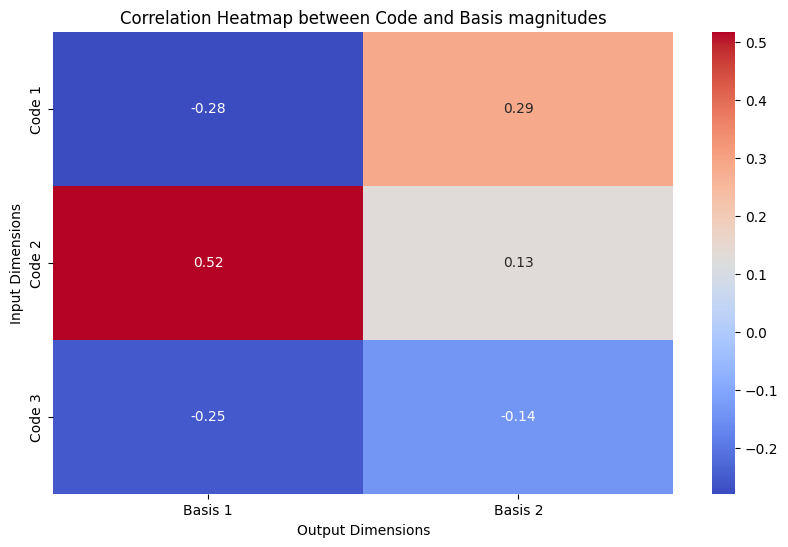

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (입력: (m, s), 출력: (m, d))
input_array = seed.detach().numpy()
output_array = mag

correlation_matrix = np.zeros((n_qubits, number_of_basis))
for i in range(n_qubits):
    for j in range(number_of_basis):
        correlation_matrix[i, j] = np.corrcoef(input_array[:, i], output_array[:, j])[0, 1]

# 시각화
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            xticklabels=[f"Basis {j+1}" for j in range(number_of_basis)], 
            yticklabels=[f"Code {i+1}" for i in range(n_qubits)])
plt.title("Correlation Heatmap between Code and Basis magnitudes")
plt.xlabel("Output Dimensions")
plt.ylabel("Input Dimensions")
plt.show()

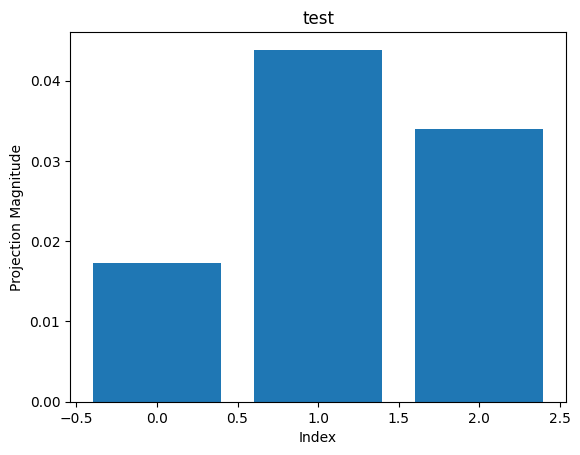

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 크기 n의 배열 (예제 데이터)
n = 3
data = magnitudes.mean(axis=0)
plt.bar(range(n), data)
plt.title("test")
plt.xlabel("Index")
plt.ylabel("Projection Magnitude")
plt.show()


In [13]:
import math
for i in range(n_qubits):
    for j in range(i+1, n_qubits):
        # calculate angle between correlation_matrix[i, :], correlation_matrix[j, :]
        cos_theta = np.dot(correlation_matrix[i, :], correlation_matrix[j, :]) / (np.linalg.norm(correlation_matrix[i, :]) * np.linalg.norm(correlation_matrix[j, :]))
        theta_degrees = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
        # 예각으로 변환
        theta_degrees = min(theta_degrees, 180 - theta_degrees)
        print(f"Code {i+1} and Code {j+1} angle: {theta_degrees}")

Code 1 and Code 2 angle: 59.80609884469091
Code 1 and Code 3 angle: 74.21473980575284
Code 2 and Code 3 angle: 14.408640961061877


In [63]:
magnitudes = np.abs(train_dataset.conjugate() @ basis_states.T)**2 # 각 output 별로 basis state가 차지하는 비중

In [69]:
train_dataset

array([[-0.07324912-0.18904633j, -0.11498721+0.08852808j,  0.31779913-0.07744424j, -0.01466337+0.45635334j, -0.07810152-0.13580436j, -0.47131207-0.48921061j, -0.01870209-0.35747119j,
        -0.05334837+0.07337066j],
       [-0.09931187-0.17498046j, -0.09342263+0.09768086j,  0.32283412-0.06898786j, -0.02253737+0.46345002j, -0.07873484-0.1107363j , -0.48181251-0.48791109j,  0.01295115-0.33731271j,
        -0.06322985+0.10181733j],
       [ 0.11594764-0.26050891j, -0.24798863+0.0136653j ,  0.24053861-0.12526219j,  0.04149513+0.34632727j, -0.06327165-0.29012738j, -0.33585418-0.43256602j, -0.23404743-0.44828528j,
         0.0218131 -0.13224974j],
       [ 0.01861888-0.23042415j, -0.18469844+0.05401187j,  0.28915483-0.10361998j,  0.01282356+0.41567765j, -0.07313031-0.21676452j, -0.41844503-0.47610459j, -0.12641237-0.41366622j,
        -0.01759953-0.02666433j],
       [ 0.20332052-0.2737342j , -0.29421738-0.02634093j,  0.17858702-0.13858812j,  0.06678367+0.25775773j, -0.04981966-0.34354961j,

In [17]:
seed = torch.empty((BATCH_SIZE, n_qubits)).uniform_(-0.5, 0.5).to(ml_device)
generator.forward(seed)

tensor([[-0.4852+0.j, -0.5357+0.j, -0.5064+0.j,  0.0376+0.j, -0.3256+0.j, -0.1390+0.j,
          0.1826+0.j, -0.2472+0.j],
        [-0.4910+0.j, -0.6117+0.j, -0.4157+0.j,  0.1368+0.j, -0.3786+0.j,  0.1586+0.j,
          0.0981+0.j, -0.1228+0.j],
        [-0.4152+0.j, -0.3278+0.j, -0.4099+0.j, -0.1697+0.j, -0.4007+0.j, -0.1929+0.j,
          0.2746+0.j, -0.5001+0.j],
        [-0.0161+0.j, -0.2696+0.j, -0.4623+0.j, -0.2547+0.j, -0.5804+0.j,  0.0019+0.j,
          0.3053+0.j, -0.4673+0.j],
        [-0.3685+0.j, -0.5812+0.j, -0.4094+0.j,  0.0195+0.j, -0.5302+0.j,  0.1236+0.j,
          0.1859+0.j, -0.1656+0.j],
        [-0.5252+0.j, -0.2588+0.j, -0.3372+0.j, -0.2498+0.j, -0.3080+0.j, -0.1613+0.j,
          0.2992+0.j, -0.5203+0.j],
        [-0.4478+0.j, -0.4726+0.j, -0.5336+0.j,  0.0625+0.j, -0.2692+0.j, -0.3344+0.j,
          0.1557+0.j, -0.2811+0.j],
        [-0.4095+0.j, -0.5789+0.j, -0.4062+0.j,  0.0414+0.j, -0.5035+0.j,  0.1407+0.j,
          0.1789+0.j, -0.1588+0.j],
        [-0.0121

In [5]:
train_tensor[0]

tensor([-0.3627, -0.4973,  0.4025,  0.0143,  0.2203,  0.1156, -0.6294,  0.0301])

In [16]:
a = torch.float32

AttributeError: 'torch.dtype' object has no attribute 'dtype'